In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
df = pd.read_csv("Diwali Sales Data.csv", encoding="unicode_escape")
df1 = df
df1.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  str    
 2   Product_ID        11251 non-null  str    
 3   Gender            11251 non-null  str    
 4   Age Group         11251 non-null  str    
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  str    
 8   Zone              11251 non-null  str    
 9   Occupation        11251 non-null  str    
 10  Product_Category  11251 non-null  str    
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), str(8)
memory usage: 1.9 MB


In [4]:
df1.isnull().sum()

User_ID                 0
Cust_name               0
Product_ID              0
Gender                  0
Age Group               0
Age                     0
Marital_Status          0
State                   0
Zone                    0
Occupation              0
Product_Category        0
Orders                  0
Amount                 12
Status              11251
unnamed1            11251
dtype: int64

In [5]:
df1.drop(['Status','unnamed1'],axis=1,inplace=True)

In [6]:
df1.duplicated().sum()

np.int64(8)

In [7]:
df1 = df1.drop_duplicates()

In [8]:
df1 = df1.ffill()

In [9]:
df1.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0


In [10]:
df1.rename(columns={"Shaadi": "Marital_Status"},inplace=True)

In [11]:
df1.describe()

,User_ID,Age,Marital_Status,Orders,Amount
count,1.124300e+04,11243.000000,11243.000000,11243.000000,11243.000000
mean,1.003005e+06,35.422841,0.420261,2.488749,9466.549091
std,1.716141e+03,12.756369,0.493623,1.114960,5233.102909
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000
25%,1.001494e+06,27.000000,0.000000,1.000000,5444.000000
50%,1.003065e+06,33.000000,0.000000,2.000000,8111.000000
75%,1.004430e+06,43.000000,1.000000,3.000000,12693.500000
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000


In [12]:
df1[['Age','Orders','Amount']].describe()

,Age,Orders,Amount
count,11243.000000,11243.000000,11243.000000
mean,35.422841,2.488749,9466.549091
std,12.756369,1.114960,5233.102909
min,12.000000,1.000000,188.000000
25%,27.000000,1.000000,5444.000000
50%,33.000000,2.000000,8111.000000
75%,43.000000,3.000000,12693.500000
max,92.000000,4.000000,23952.000000


In [13]:
df1.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='str')

## Exploratary Data Analysis

### Gender

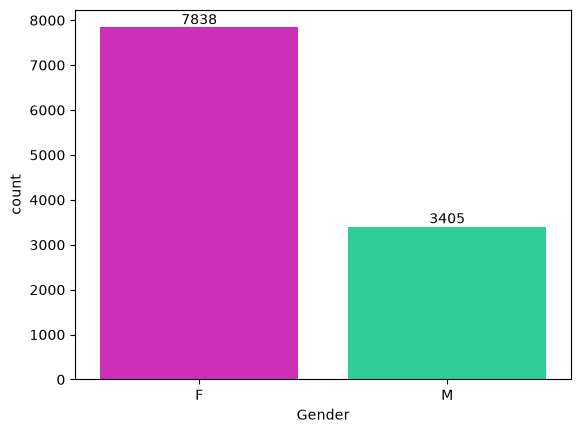

In [14]:
colors = ["#e815cc", "#15e8a2"]

ax = sns.countplot(
    x="Gender",
    data=df1,
    hue="Gender",
    palette=colors,
    legend=False
)

for bars in ax.containers:
    ax.bar_label(bars)

<Axes: xlabel='Gender'>

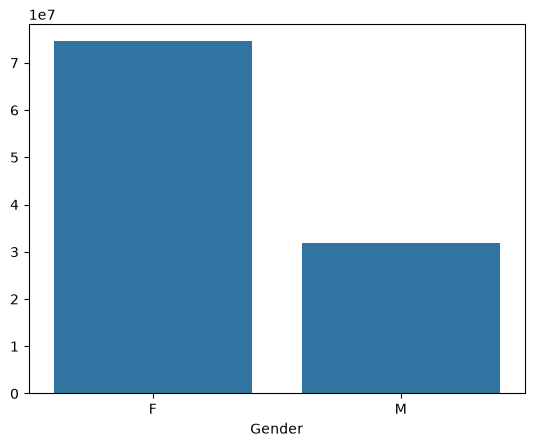

In [15]:
sales_gen = df1.groupby('Gender')['Amount'].sum().sort_values(ascending=False)

sns.barplot(x=sales_gen.index,y=sales_gen.values)

### from this visualization we can see that females are buying more worth products then men

### Age

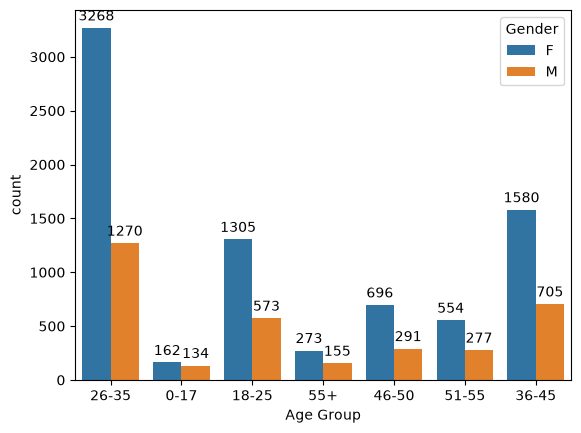

In [16]:
ax = sns.countplot(x="Age Group",hue="Gender",data=df1)
for bars in ax.containers:
    ax.bar_label(bars,padding=3)

In [17]:
print(df1.columns.tolist())

['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age', 'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category', 'Orders', 'Amount']


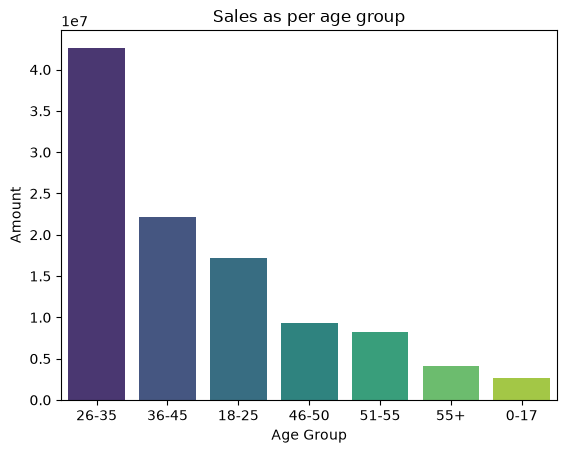

In [18]:
sales_age = df1.groupby("Age Group")["Amount"].sum().sort_values(ascending=False).reset_index()
plt.title("Sales as per age group")
sns.barplot(x="Age Group",y="Amount",data=sales_age,hue="Age Group",palette="viridis")
plt.show()

### as those two graphs are saying that age group 26-35 Females are buying more worth product than others

### State

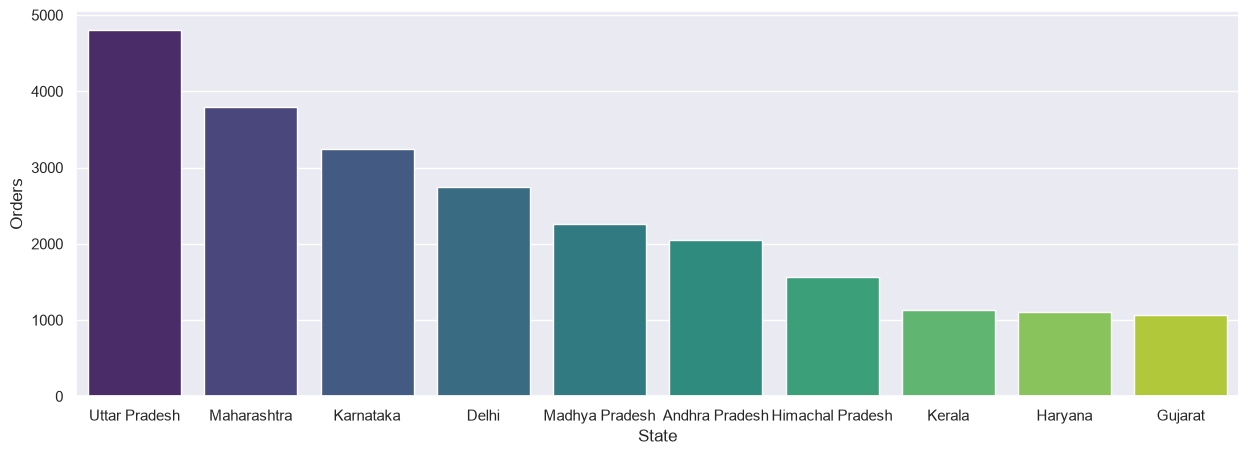

In [19]:
sales_state = df1.groupby(['State'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)

sns.set(rc={'figure.figsize':(15,5)})
sns.barplot(data = sales_state, x = 'State',y= 'Orders',palette="viridis",hue='State',legend=False)

plt.show()

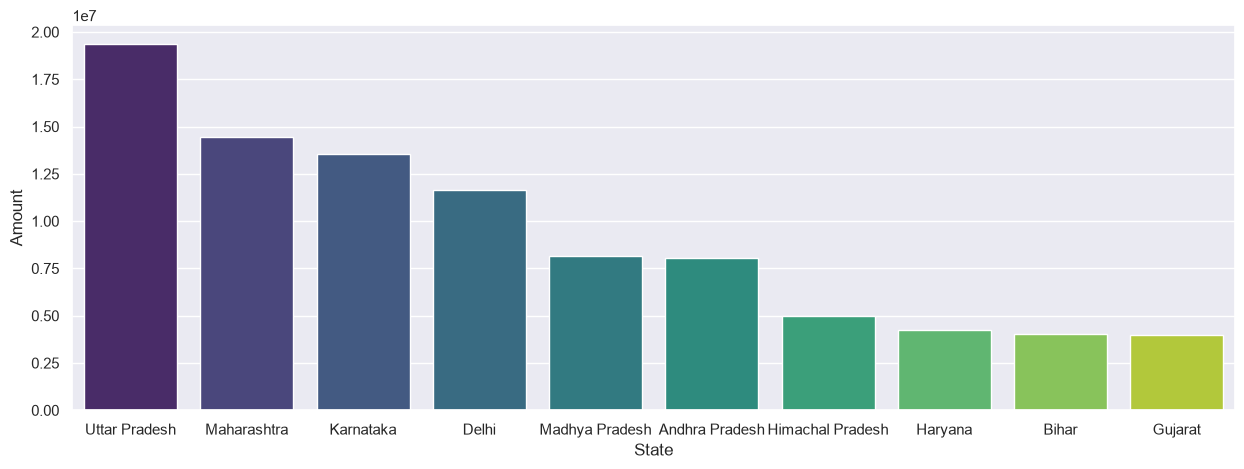

In [20]:
sales_state = df1.groupby(['State'], as_index=False)['Amount'].sum().sort_values(by="Amount",ascending=False).head(10)

sns.set(rc={'figure.figsize':(15,5)})
sns.barplot(data = sales_state, x = 'State',y= 'Amount',palette="viridis",hue='State',legend=False)

plt.show()

### By this visualization we can see that Uttar Pradesh is the state that is make most order and spent money rather than others

### Marital Status

In [21]:
print(df1.columns.to_list())

['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age', 'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category', 'Orders', 'Amount']


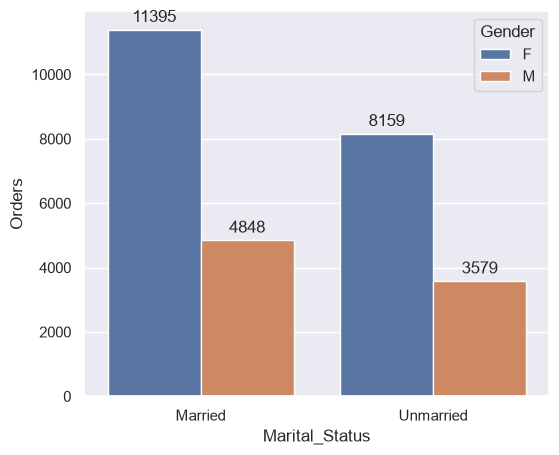

In [22]:
df1["Marital_Status"] = df1["Marital_Status"].map({0: "Married",1:"Unmarried"})

sns.set(rc={'figure.figsize':(6,5)})
sales_martial = df1.groupby(["Marital_Status","Gender"])["Orders"].sum().reset_index()
ax = sns.barplot(x="Marital_Status", y="Orders", data=sales_martial, hue='Gender', legend=True)

for bars in ax.containers:
    ax.bar_label(bars, padding=3)
plt.show()

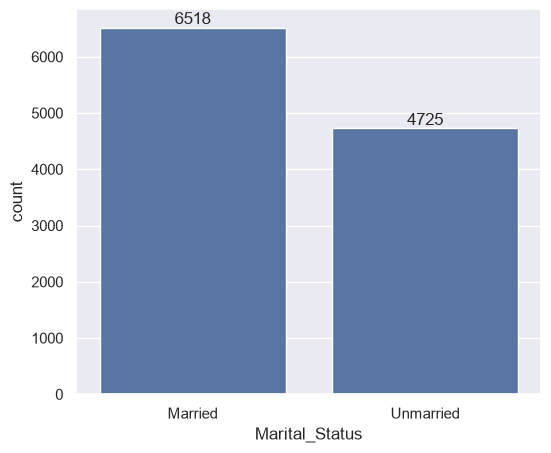

In [23]:
ax = sns.countplot(data=df1, x="Marital_Status")

sns.set(rc={'figure.figsize':(7,5)})
for bars in ax.containers:
    ax.bar_label(bars)

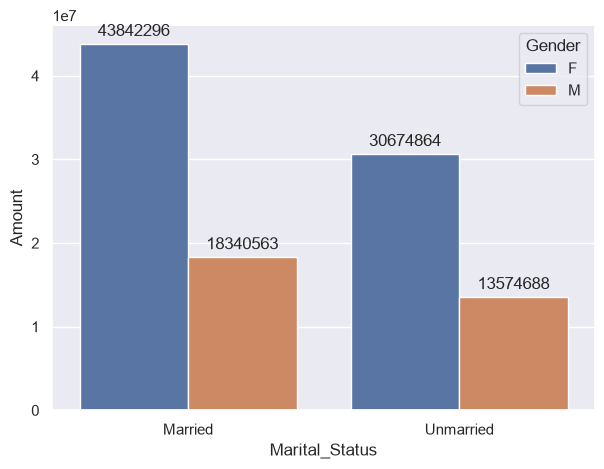

In [24]:
sales_martial = df1.groupby(["Marital_Status","Gender"])["Amount"].sum().reset_index()
ax = sns.barplot(x="Marital_Status", y="Amount", data=sales_martial,  hue='Gender')

for bars in ax.containers:
    ax.bar_label(bars, padding=3, fmt='%.0f')

plt.show()

### As per this two graph we can see that Married peoples are ordering and spending money over Unmarried one and also females are buying more than male

In [25]:
df1.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,Married,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,Unmarried,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,Unmarried,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,Married,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,Unmarried,Gujarat,Western,Food Processing,Auto,2,23877.0


### Occupation

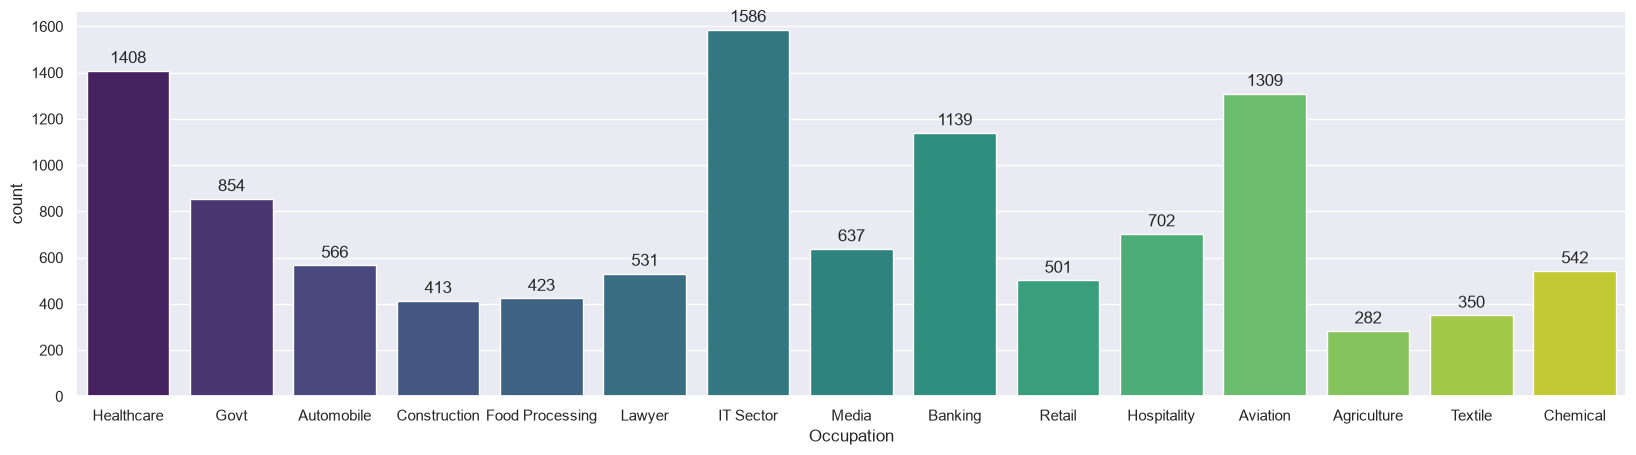

In [26]:
sns.set(rc={'figure.figsize':(20,5)})
ax = sns.countplot(data = df1,x = 'Occupation',palette="viridis",hue='Occupation',legend=False) 

for bars in ax.containers:
    ax.bar_label(bars, padding=3, fmt='%.0f')
plt.show()

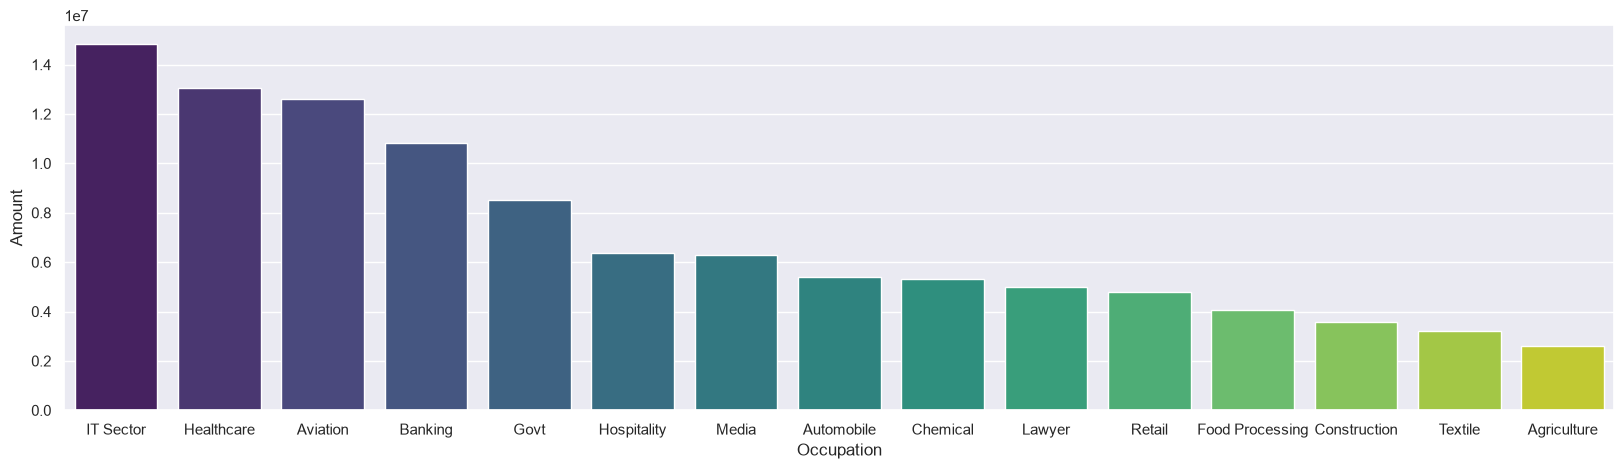

In [27]:
sales_state = df1.groupby("Occupation")["Amount"].sum().sort_values(ascending=False).reset_index()
sns.set(rc ={'figure.figsize':(20,5)})
sns.barplot(data=sales_state,x="Occupation",y="Amount",palette="viridis",hue='Occupation',legend=False)
plt.show()

#### By this visualiztion  we can see that mostly __IT sectors__ is the top most buyers of this company. After that health care, aviation industry are there.. 

### Producting Category

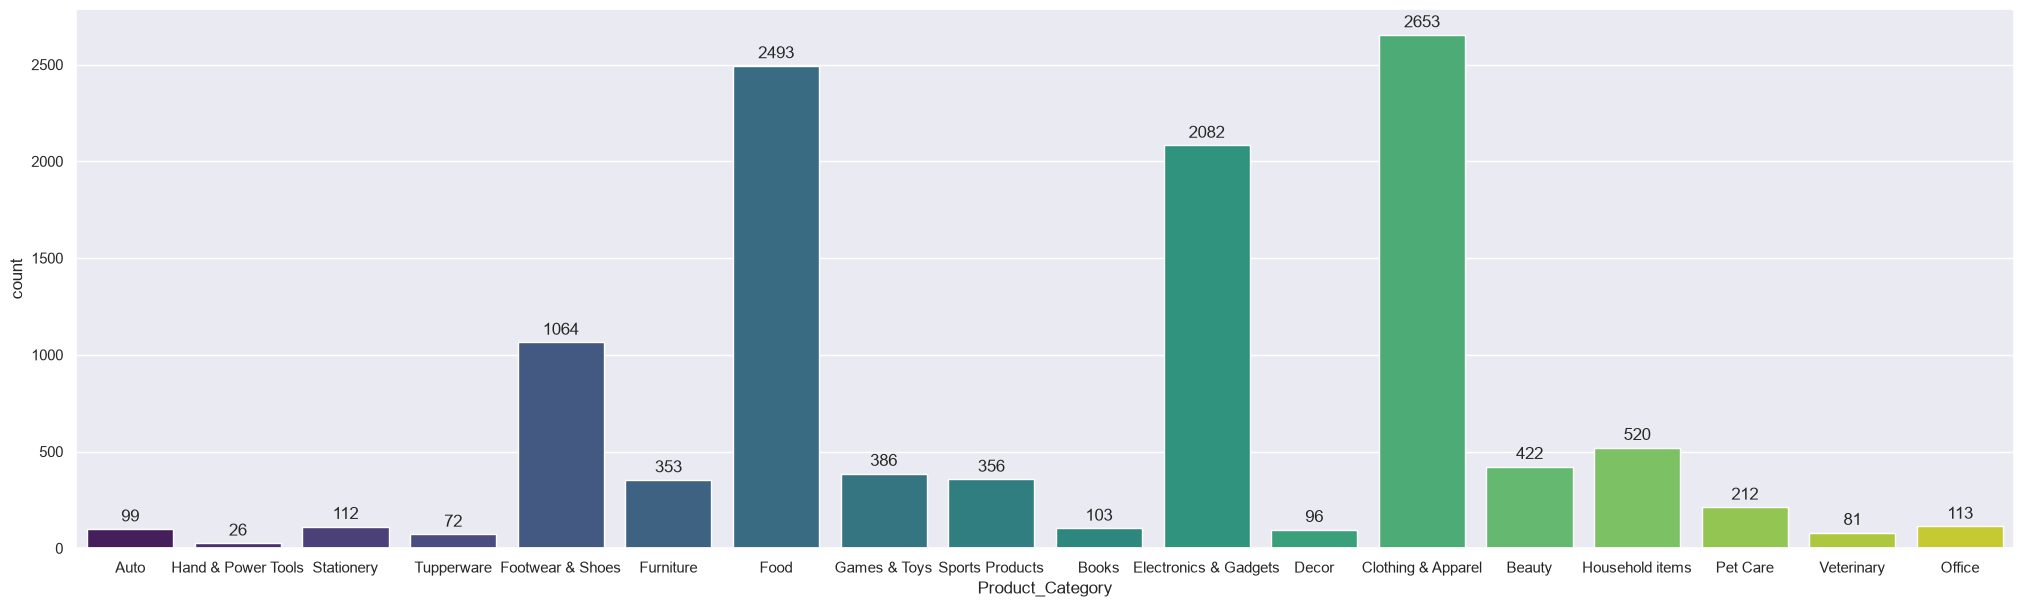

In [28]:
sns.set(rc={'figure.figsize':(25,7)})
ax = sns.countplot(data = df1,x = 'Product_Category',palette="viridis",hue='Product_Category',legend=False) 

for bars in ax.containers:
    ax.bar_label(bars, padding=3, fmt='%.0f')
plt.show()

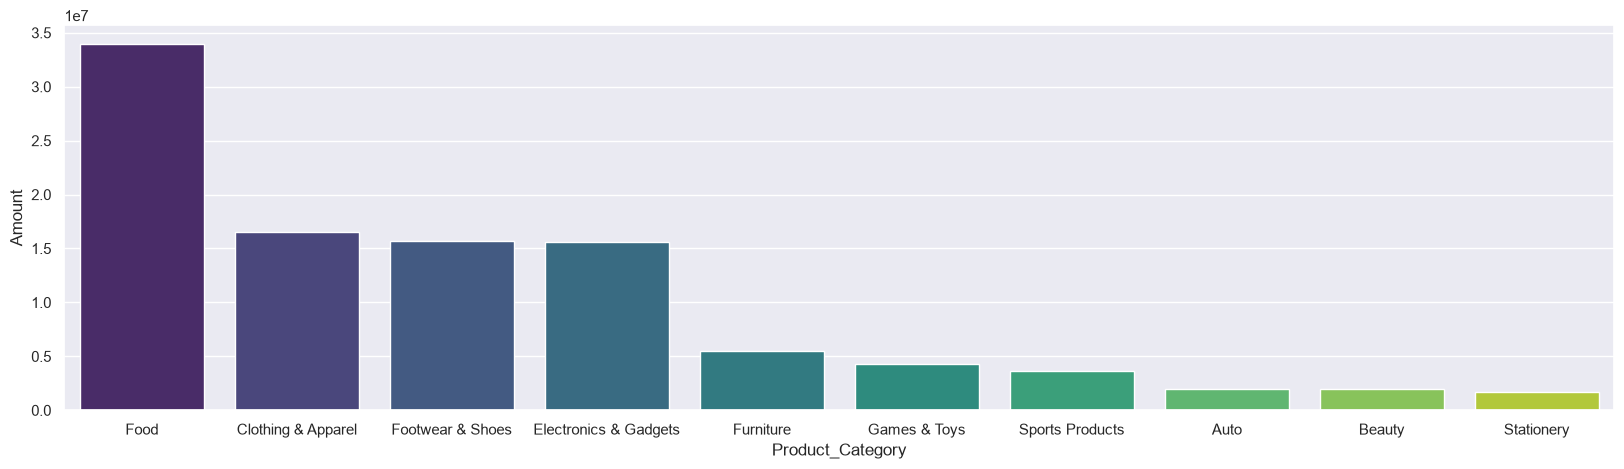

In [29]:
sales_state = df1.groupby("Product_Category")["Amount"].sum().sort_values(ascending=False).reset_index().head(10)
sns.set(rc ={'figure.figsize':(20,5)})
sns.barplot(data=sales_state,x="Product_Category",y="Amount",palette="viridis",hue='Product_Category',legend=False)
plt.show()

### From this visualization we can see most of the product are sold from food and clothing footwear etc 

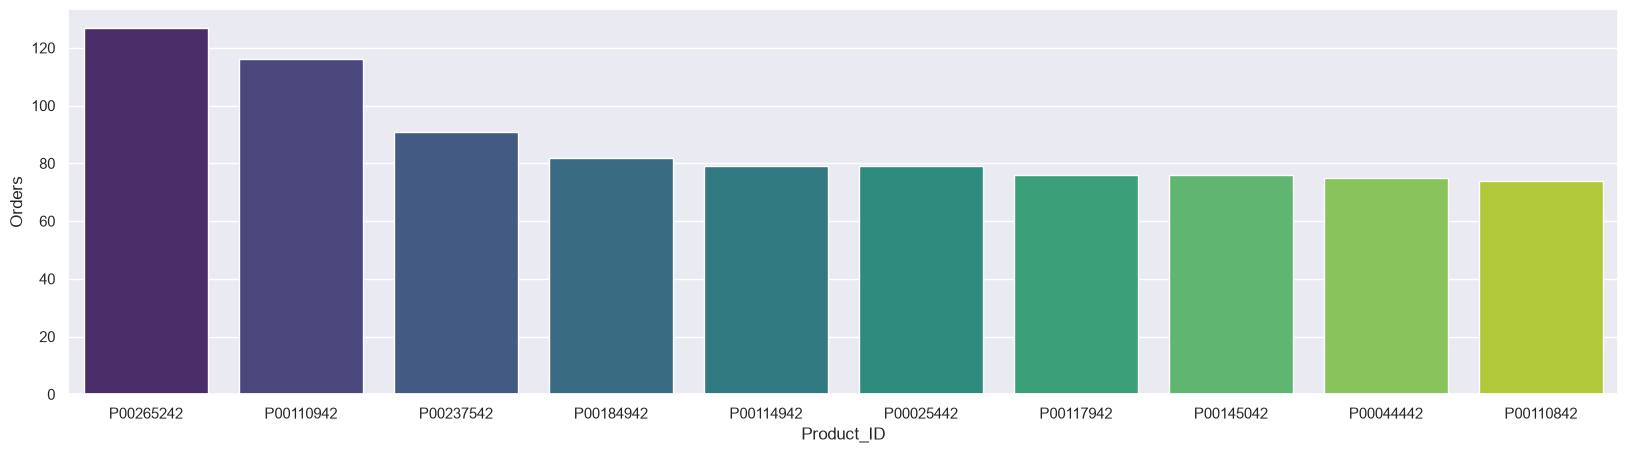

In [33]:
sales_state = df.groupby('Product_ID')['Orders'].sum().sort_values(ascending=False).reset_index().head(10)
sns.set(rc={'figure.figsize':(20,5)})
sns.barplot(data=sales_state,x="Product_ID",y="Orders",palette="viridis",hue="Product_ID",legend=False)
plt.show()

In [39]:
top_products = ["P00265242","P00110942","P00237542","P00184942"]
df1[df1["Product_ID"].isin(top_products)][["Product_ID", "Product_Category"]].drop_duplicates().head(10)

,Product_ID,Product_Category
1,P00110942,Auto
62,P00265242,Stationery
113,P00184942,Stationery
188,P00110942,Furniture
208,P00265242,Furniture
219,P00184942,Footwear & Shoes
278,P00110942,Footwear & Shoes
349,P00265242,Footwear & Shoes
470,P00184942,Food
527,P00237542,Food


## Conclusion

- **Married women aged 26–35** are the biggest buyers, purchasing more products than any other segment.
- **Top 4 states by sales:** Uttar Pradesh, Maharashtra, Karnataka, and Delhi.
- **Top occupations:** Buyers from **IT, Healthcare, and Aviation** sectors purchase comparatively more than other occupations.
- **Category trends:** Food, Clothing, and Footwear are the top-selling categories. Though Clothing has more orders overall, **Food generates more revenue**.

#### Top-selling products and their categories:

| Product ID | Category |
|---|---|
| P00265242 | Stationery |
| P00110942 | Auto |
| P00237542 | Food |
| P00184942 | Footwear and Shoes |

### Thanks for checking my code!

**Keep learning, keep analyzing!!**

— *Priyajit*